In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
column_names = ["id", "topic", "sentiment", "text"]
df  = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/twitter_training.csv',names =column_names)
df.head(20)

,id,topic,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
5,2401,Borderlands,Positive,im getting into borderlands and i can murder y...
6,2402,Borderlands,Positive,So I spent a few hours making something for fu...
7,2402,Borderlands,Positive,So I spent a couple of hours doing something f...
8,2402,Borderlands,Positive,So I spent a few hours doing something for fun...
9,2402,Borderlands,Positive,So I spent a few hours making something for fu...


In [ ]:
df.drop(columns=['id', 'topic'], inplace=True)

In [ ]:
df

,sentiment,text
0,Positive,im getting on borderlands and i will murder yo...
1,Positive,I am coming to the borders and I will kill you...
2,Positive,im getting on borderlands and i will kill you ...
3,Positive,im coming on borderlands and i will murder you...
4,Positive,im getting on borderlands 2 and i will murder ...
...,...,...
74677,Positive,Just realized that the Windows partition of my...
74678,Positive,Just realized that my Mac window partition is ...
74679,Positive,Just realized the windows partition of my Mac ...
74680,Positive,Just realized between the windows partition of...


In [ ]:
df['text'][878]

'Holy shit borderlands 3 is ass.'

## Remove Irrelevant and Neutral

In [ ]:
# Step 2: Clean whitespaces and lowercase all sentiment labels
df['sentiment'] = df['sentiment'].str.strip().str.lower()

# Step 3: Filter to keep only 'positive' and 'negative'
df = df[df['sentiment'].isin(['positive', 'negative'])]

# Step 4: Reset index (optional)
df = df.reset_index(drop=True)

# Step 5: Confirm the result
print(df['sentiment'].value_counts())



sentiment
negative    22542
positive    20832
Name: count, dtype: int64


In [ ]:
df.to_csv("twitter_Sentiment_Analysis", index= False)

In [ ]:
df.shape

(43374, 2)

In [ ]:
len(df)

43374

In [ ]:
df.isnull().sum()

,0
sentiment,0
text,361


In [ ]:
df.dropna(subset=['text'],inplace=True)
df

,sentiment,text
0,positive,im getting on borderlands and i will murder yo...
1,positive,I am coming to the borders and I will kill you...
2,positive,im getting on borderlands and i will kill you ...
3,positive,im coming on borderlands and i will murder you...
4,positive,im getting on borderlands 2 and i will murder ...
...,...,...
43369,positive,Just realized that the Windows partition of my...
43370,positive,Just realized that my Mac window partition is ...
43371,positive,Just realized the windows partition of my Mac ...
43372,positive,Just realized between the windows partition of...


In [ ]:
df.isnull().sum()

,0
sentiment,0
text,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43013 entries, 0 to 43373
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  43013 non-null  object
 1   text       43013 non-null  object
dtypes: object(2)
memory usage: 1008.1+ KB


In [ ]:
df.isnull().sum()

,0
sentiment,0
text,0


In [ ]:
df.sentiment.value_counts()

,count
sentiment,
negative,22358
positive,20655


## Merge Neutral and Irrelevant

## Remove Neutral and Irrelevant

In [ ]:
df.sentiment.value_counts()

,count
sentiment,
negative,22358
positive,20655


Sentiment distribution

In [ ]:
df.shape

(43013, 2)

In [ ]:
sentiment_counts = df['sentiment'].value_counts()
print("\nSentiment Distribution:")
for sentiment, count in sentiment_counts.items():
    percentage = (count / len(df)) * 100
    print(f"Class {sentiment}: {count} ({percentage:.1f}%)")


Sentiment Distribution:
Class negative: 22358 (52.0%)
Class positive: 20655 (48.0%)


Text statistics

In [ ]:
print(f"\nText Statistics:")
print(f"Average text length: {df['text'].str.len().mean():.1f} characters")
print(f"Longest text: {df['text'].str.len().max()} characters")
print(f"Shortest text: {df['text'].str.len().min()} characters")


Text Statistics:
Average text length: 103.9 characters
Longest text: 727 characters
Shortest text: 1 characters


Plot sentiment distribution

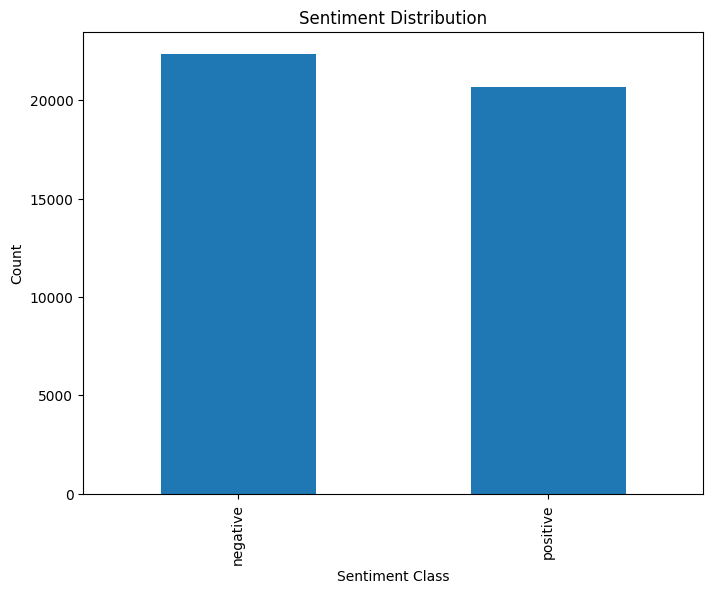

In [ ]:
plt.figure(figsize=(8, 6))
df['sentiment'].value_counts().plot(kind='bar')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment Class')
plt.ylabel('Count')
plt.show()

In [ ]:
df.duplicated().sum()

np.int64(2638)

there are 2638 duplicate reviews so remove them

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["text"][12263]

'<unk>...I think CS:GO ruined it for me<unk>. People had so much fun playing CS today and when I jumped on Valorant I just caused it to fall over.'

In [ ]:
df.isnull().sum()

,0
sentiment,0
text,0


In [ ]:
df.shape


(40375, 2)

In [ ]:
df.dropna(inplace=True)


In [ ]:
df.isnull().sum()

,0
sentiment,0
text,0


In [ ]:
df.shape

(40375, 2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40375 entries, 0 to 43373
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  40375 non-null  object
 1   text       40375 non-null  object
dtypes: object(2)
memory usage: 1.9+ MB


In [ ]:
df.describe()

,sentiment,text
count,40375,40375
unique,2,40287
top,negative,The
freq,21237,2


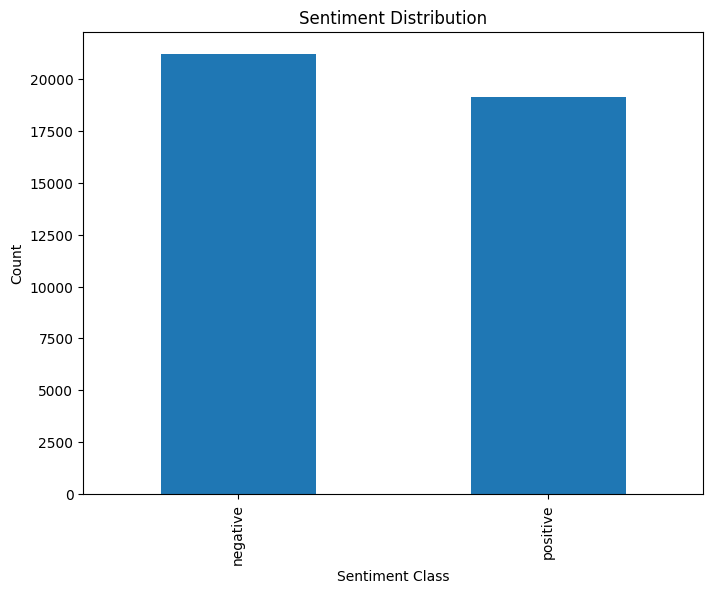

In [ ]:
plt.figure(figsize=(8, 6))
df['sentiment'].value_counts().plot(kind='bar')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment Class')
plt.ylabel('Count')
plt.show()

## Basic Preprocessing




Remove tags

Lower case

Remove stopword

Spelling correction

Remove Punctuation

In [ ]:
import re

# Function to remove HTML tags and @mentions
def clean_text(text):
    text = re.sub(r'<.*?>', '', text)    # Remove HTML tags
    text = re.sub(r'@\w+', '', text)     # Remove @mentions
    return text.strip()

# Apply the function on the 'text' column
df['text'] = df['text'].apply(clean_text)

# Optional: Preview cleaned text with sentiment
print(df[['text', 'sentiment']].head())

                                                text sentiment
0  im getting on borderlands and i will murder yo...  positive
1  I am coming to the borders and I will kill you...  positive
2  im getting on borderlands and i will kill you ...  positive
3  im coming on borderlands and i will murder you...  positive
4  im getting on borderlands 2 and i will murder ...  positive


In [ ]:
df['text'] = df['text'].apply(clean_text)

In [ ]:
df['text'][12263]

'...I think CS:GO ruined it for me. People had so much fun playing CS today and when I jumped on Valorant I just caused it to fall over.'

In [ ]:
df['text'] = df['text'].apply(lambda x:x.lower())

In [ ]:
df['text'][25456]

"today i have switched at back to verizon i now have some oann and newsmax. haven'n t watched fox again since fox and friends. but it's had a great day."

In [ ]:
import pandas as pd
import re

# Function to clean HTML tags, @mentions, and slashes
def clean_text(text):
    text = re.sub(r'<.*?>', '', text)    # Remove HTML tags
    text = re.sub(r'@\w+', '', text)     # Remove @mentions
    text = text.replace('/', '')         # Remove forward slashes
    return text.strip()

# Apply the function to the 'text' column
df['text'] = df['text'].apply(clean_text)

# Optional: View the cleaned text
print(df[['text', 'sentiment']].head())


                                                text sentiment
0  im getting on borderlands and i will murder yo...  positive
1  i am coming to the borders and i will kill you...  positive
2  im getting on borderlands and i will kill you ...  positive
3  im coming on borderlands and i will murder you...  positive
4  im getting on borderlands 2 and i will murder ...  positive


In [ ]:
df['text'][25456]

"today i have switched at back to verizon i now have some oann and newsmax. haven'n t watched fox again since fox and friends. but it's had a great day."

In [ ]:
import pandas as pd
import re

def clean_text(text):
    text = re.sub(r'<.*?>', '', text)     # Remove HTML tags
    text = re.sub(r'@\w+', '', text)      # Remove @mentions
    text = text.replace('/', '')          # Remove slashes
    text = re.sub(r'\d+', '', text)       # Remove digits
    return text.strip()

# Apply to 'text' column
df['text'] = df['text'].apply(clean_text)

# View cleaned data
print(df[['text', 'sentiment']].head())


                                                text sentiment
0  im getting on borderlands and i will murder yo...  positive
1  i am coming to the borders and i will kill you...  positive
2  im getting on borderlands and i will kill you ...  positive
3  im coming on borderlands and i will murder you...  positive
4  im getting on borderlands  and i will murder y...  positive


In [ ]:
df['text'][25456]

"today i have switched at back to verizon i now have some oann and newsmax. haven'n t watched fox again since fox and friends. but it's had a great day."

In [ ]:
import re

def clean_text(text):
    # Step 1: Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Step 2: Remove all digits and special characters you listed
    text = re.sub(r'[\/#@!&*%$><?~.,|:;\'"\d]', '', text)

    # Optional: remove extra spaces
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

In [ ]:
df['text'] = df['text'].apply(clean_text)


In [ ]:
df['text'][25456]

'today i have switched at back to verizon i now have some oann and newsmax havenn t watched fox again since fox and friends but its had a great day'

stopword not found first should download

In [ ]:
import nltk
from nltk.corpus import stopwords

# If not downloaded already, run this line once
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# Remove stopword

In [ ]:
from nltk.corpus import stopwords
sw_list = stopwords.words('english')

df['new_review'] = df['text'].apply(lambda x: [item for item in x.split() if item not in sw_list]).apply(lambda x:" ".join(x))

In [ ]:
df

,sentiment,text,new_review
0,positive,im getting on borderlands and i will murder yo...,im getting borderlands murder
1,positive,i am coming to the borders and i will kill you...,coming borders kill
2,positive,im getting on borderlands and i will kill you all,im getting borderlands kill
3,positive,im coming on borderlands and i will murder you...,im coming borderlands murder
4,positive,im getting on borderlands and i will murder yo...,im getting borderlands murder
...,...,...,...
43369,positive,just realized that the windows partition of my...,realized windows partition mac like years behi...
43370,positive,just realized that my mac window partition is ...,realized mac window partition years behind nvi...
43371,positive,just realized the windows partition of my mac ...,realized windows partition mac years behind nv...
43372,positive,just realized between the windows partition of...,realized windows partition mac like years behi...


In [ ]:
df.drop(columns=['text'], inplace=True)

In [ ]:
df

,sentiment,new_review
0,positive,im getting borderlands murder
1,positive,coming borders kill
2,positive,im getting borderlands kill
3,positive,im coming borderlands murder
4,positive,im getting borderlands murder
...,...,...
43369,positive,realized windows partition mac like years behi...
43370,positive,realized mac window partition years behind nvi...
43371,positive,realized windows partition mac years behind nv...
43372,positive,realized windows partition mac like years behi...


In [ ]:
df

,sentiment,new_review
0,positive,im getting borderlands murder
1,positive,coming borders kill
2,positive,im getting borderlands kill
3,positive,im coming borderlands murder
4,positive,im getting borderlands murder
...,...,...
43369,positive,realized windows partition mac like years behi...
43370,positive,realized mac window partition years behind nvi...
43371,positive,realized windows partition mac years behind nv...
43372,positive,realized windows partition mac like years behi...


In [ ]:
df['new_review'][10]

'spent hours making something fun dont know huge rhandlerr fan maya one favorite characters decided make wallpaper pc original image versus creation made ) enjoy pictwittercommlsiwfjg'

# Remove punctuation

In [ ]:
import re

def remove_punctuation(text):
    return re.sub(r'[^\w\s]', '', text)

df['review'] = df['new_review'].apply(lambda x: remove_punctuation(x.lower()))


In [ ]:
df

,sentiment,new_review,review
0,positive,im getting borderlands murder,im getting borderlands murder
1,positive,coming borders kill,coming borders kill
2,positive,im getting borderlands kill,im getting borderlands kill
3,positive,im coming borderlands murder,im coming borderlands murder
4,positive,im getting borderlands murder,im getting borderlands murder
...,...,...,...
43369,positive,realized windows partition mac like years behi...,realized windows partition mac like years behi...
43370,positive,realized mac window partition years behind nvi...,realized mac window partition years behind nvi...
43371,positive,realized windows partition mac years behind nv...,realized windows partition mac years behind nv...
43372,positive,realized windows partition mac like years behi...,realized windows partition mac like years behi...


In [ ]:
df.drop(columns=['new_review'], inplace=True)

In [ ]:
df

,sentiment,review
0,positive,im getting borderlands murder
1,positive,coming borders kill
2,positive,im getting borderlands kill
3,positive,im coming borderlands murder
4,positive,im getting borderlands murder
...,...,...
43369,positive,realized windows partition mac like years behi...
43370,positive,realized mac window partition years behind nvi...
43371,positive,realized windows partition mac years behind nv...
43372,positive,realized windows partition mac like years behi...


check emoji

In [ ]:
!pip install emoji


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 10.8 MB/s eta 0:00:00


# Using Regex for Emoji Detection



In [ ]:
import re

emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons 🙂
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs 💡
                           u"\U0001F680-\U0001F6FF"  # transport 🚗
                           u"\U0001F1E0-\U0001F1FF"  # flags 🇮🇳
                           "]+", flags=re.UNICODE)

def contains_emoji(text):
    return bool(emoji_pattern.search(text))

print(contains_emoji("Awesome 🔥🔥🔥"))  # True
print(contains_emoji("No emojis here"))  # False


True
False


# Want to Remove Emojis



In [ ]:
def remove_emoji(text):
    return emoji_pattern.sub(r'', text)


In [ ]:
df

,sentiment,review
0,positive,im getting borderlands murder
1,positive,coming borders kill
2,positive,im getting borderlands kill
3,positive,im coming borderlands murder
4,positive,im getting borderlands murder
...,...,...
43369,positive,realized windows partition mac like years behi...
43370,positive,realized mac window partition years behind nvi...
43371,positive,realized windows partition mac years behind nv...
43372,positive,realized windows partition mac like years behi...


# Tokenization using Regular Expressions


In [ ]:
def regex_tokenize(text):
    return re.findall(r'\b\w+\b', text)

df['tokens_regex'] = df['review'].apply(regex_tokenize)

In [ ]:
###df2.drop(columns = ['tokens_regex'], inplace =True)

In [ ]:
df

,sentiment,review,tokens_regex
0,positive,im getting borderlands murder,"[im, getting, borderlands, murder]"
1,positive,coming borders kill,"[coming, borders, kill]"
2,positive,im getting borderlands kill,"[im, getting, borderlands, kill]"
3,positive,im coming borderlands murder,"[im, coming, borderlands, murder]"
4,positive,im getting borderlands murder,"[im, getting, borderlands, murder]"
...,...,...,...
43369,positive,realized windows partition mac like years behi...,"[realized, windows, partition, mac, like, year..."
43370,positive,realized mac window partition years behind nvi...,"[realized, mac, window, partition, years, behi..."
43371,positive,realized windows partition mac years behind nv...,"[realized, windows, partition, mac, years, beh..."
43372,positive,realized windows partition mac like years behi...,"[realized, windows, partition, mac, like, year..."


# 🔹 2. NLTK Tokenization


Install NLTK

In [ ]:
!pip install nltk


In [ ]:
import nltk
nltk.download('punkt')

from nltk.tokenize import word_tokenize

# Assuming your DataFrame is named df1 and the column is 'review'
df2['tokens'] = df2['review'].apply(lambda x: word_tokenize(str(x)))


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


In [ ]:
import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize

df2['tokens_nltk'] = df2['review'].apply(word_tokenize)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


#🔹 3. spaCy Tokenization


In [ ]:
!pip install spacy
!python -m spacy download en_core_web_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 116.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy

nlp = spacy.load("en_core_web_sm")

def spacy_tokenize(review):
    doc = nlp(review)
    return [token.text for token in doc]

df['tokens_spacy'] = df['review'].apply(spacy_tokenize)

In [ ]:
###df[['text', 'clean_text', 'tokens_regex', 'tokens_nltk', 'tokens_spacy']].head()


In [ ]:
df

,sentiment,review,tokens_regex,tokens_spacy
0,positive,im getting borderlands murder,"[im, getting, borderlands, murder]","[i, m, getting, borderlands, murder]"
1,positive,coming borders kill,"[coming, borders, kill]","[coming, borders, kill]"
2,positive,im getting borderlands kill,"[im, getting, borderlands, kill]","[i, m, getting, borderlands, kill]"
3,positive,im coming borderlands murder,"[im, coming, borderlands, murder]","[i, m, coming, borderlands, murder]"
4,positive,im getting borderlands murder,"[im, getting, borderlands, murder]","[i, m, getting, borderlands, murder]"
...,...,...,...,...
43369,positive,realized windows partition mac like years behi...,"[realized, windows, partition, mac, like, year...","[realized, windows, partition, mac, like, year..."
43370,positive,realized mac window partition years behind nvi...,"[realized, mac, window, partition, years, behi...","[realized, mac, window, partition, years, behi..."
43371,positive,realized windows partition mac years behind nv...,"[realized, windows, partition, mac, years, beh...","[realized, windows, partition, mac, years, beh..."
43372,positive,realized windows partition mac like years behi...,"[realized, windows, partition, mac, like, year...","[realized, windows, partition, mac, like, year..."


In [ ]:
df[[ 'tokens_spacy']].head()

,tokens_spacy
0,"[i, m, getting, borderlands, murder]"
1,"[coming, borders, kill]"
2,"[i, m, getting, borderlands, kill]"
3,"[i, m, coming, borderlands, murder]"
4,"[i, m, getting, borderlands, murder]"


In [ ]:
import spacy
nlp = spacy.load("en_core_web_sm")
df['tokens'] = df2['tokens_spacy'].apply(lambda text: [token.text for token in nlp('text')])


NameError: name 'df2' is not defined

In [ ]:
df

,sentiment,review,tokens_regex,tokens_spacy
0,positive,im getting borderlands murder,"[im, getting, borderlands, murder]","[i, m, getting, borderlands, murder]"
1,positive,coming borders kill,"[coming, borders, kill]","[coming, borders, kill]"
2,positive,im getting borderlands kill,"[im, getting, borderlands, kill]","[i, m, getting, borderlands, kill]"
3,positive,im coming borderlands murder,"[im, coming, borderlands, murder]","[i, m, coming, borderlands, murder]"
4,positive,im getting borderlands murder,"[im, getting, borderlands, murder]","[i, m, getting, borderlands, murder]"
...,...,...,...,...
43369,positive,realized windows partition mac like years behi...,"[realized, windows, partition, mac, like, year...","[realized, windows, partition, mac, like, year..."
43370,positive,realized mac window partition years behind nvi...,"[realized, mac, window, partition, years, behi...","[realized, mac, window, partition, years, behi..."
43371,positive,realized windows partition mac years behind nv...,"[realized, windows, partition, mac, years, beh...","[realized, windows, partition, mac, years, beh..."
43372,positive,realized windows partition mac like years behi...,"[realized, windows, partition, mac, like, year...","[realized, windows, partition, mac, like, year..."


Lemmatization

In [ ]:

import nltk
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

# Assume df['tokens'] is a list of word tokens
df['lemmatized'] = df['tokens_spacy'].apply(
    lambda tokens: [lemmatizer.lemmatize(token) for token in tokens]
)

# Join back into text for vectorizers that expect strings
df['processed_text'] = df['lemmatized'].apply(lambda tokens: ' '.join(tokens))


[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
df

,sentiment,review,tokens_regex,tokens_spacy,lemmatized,processed_text
0,positive,im getting borderlands murder,"[im, getting, borderlands, murder]","[i, m, getting, borderlands, murder]","[i, m, getting, borderland, murder]",i m getting borderland murder
1,positive,coming borders kill,"[coming, borders, kill]","[coming, borders, kill]","[coming, border, kill]",coming border kill
2,positive,im getting borderlands kill,"[im, getting, borderlands, kill]","[i, m, getting, borderlands, kill]","[i, m, getting, borderland, kill]",i m getting borderland kill
3,positive,im coming borderlands murder,"[im, coming, borderlands, murder]","[i, m, coming, borderlands, murder]","[i, m, coming, borderland, murder]",i m coming borderland murder
4,positive,im getting borderlands murder,"[im, getting, borderlands, murder]","[i, m, getting, borderlands, murder]","[i, m, getting, borderland, murder]",i m getting borderland murder
...,...,...,...,...,...,...
43369,positive,realized windows partition mac like years behi...,"[realized, windows, partition, mac, like, year...","[realized, windows, partition, mac, like, year...","[realized, window, partition, mac, like, year,...",realized window partition mac like year behind...
43370,positive,realized mac window partition years behind nvi...,"[realized, mac, window, partition, years, behi...","[realized, mac, window, partition, years, behi...","[realized, mac, window, partition, year, behin...",realized mac window partition year behind nvid...
43371,positive,realized windows partition mac years behind nv...,"[realized, windows, partition, mac, years, beh...","[realized, windows, partition, mac, years, beh...","[realized, window, partition, mac, year, behin...",realized window partition mac year behind nvid...
43372,positive,realized windows partition mac like years behi...,"[realized, windows, partition, mac, like, year...","[realized, windows, partition, mac, like, year...","[realized, window, partition, mac, like, year,...",realized window partition mac like year behind...


In [ ]:
df1 = df.drop(columns=['tokens_spacy','lemmatized','review','tokens_regex'])

In [ ]:
df1

,sentiment,processed_text
0,positive,i m getting borderland murder
1,positive,coming border kill
2,positive,i m getting borderland kill
3,positive,i m coming borderland murder
4,positive,i m getting borderland murder
...,...,...
43369,positive,realized window partition mac like year behind...
43370,positive,realized mac window partition year behind nvid...
43371,positive,realized window partition mac year behind nvid...
43372,positive,realized window partition mac like year behind...


In [ ]:
# Before tokenization/lemmatization, normalize contractions
import re

def expand_contractions(text):
    # Replace I’m, you’re, we’re, they’re, etc.
    text = re.sub(r"\b i m\b", "i am", text, flags=re.IGNORECASE)
    text = re.sub(r"\b(\w+)’m\b", r"\1 am", text)  # handles “I’m” and others like “you’re” if desired
    return text

# Apply to your DataFrame’s text column
df1['Tweet'] = df1['processed_text'].apply(expand_contractions)


In [ ]:
df1

,sentiment,processed_text,Tweet
0,positive,i m getting borderland murder,i m getting borderland murder
1,positive,coming border kill,coming border kill
2,positive,i m getting borderland kill,i m getting borderland kill
3,positive,i m coming borderland murder,i m coming borderland murder
4,positive,i m getting borderland murder,i m getting borderland murder
...,...,...,...
43369,positive,realized window partition mac like year behind...,realized window partition mac like year behind...
43370,positive,realized mac window partition year behind nvid...,realized mac window partition year behind nvid...
43371,positive,realized window partition mac year behind nvid...,realized window partition mac year behind nvid...
43372,positive,realized window partition mac like year behind...,realized window partition mac like year behind...


In [ ]:
# Fix “i m” to “i am”
df1['Tweets'] = df1['processed_text'].str.replace(r'\bi m\b', 'i am', regex=True)


In [ ]:
df1

,sentiment,processed_text,Tweet,Tweets
0,positive,i m getting borderland murder,i m getting borderland murder,i am getting borderland murder
1,positive,coming border kill,coming border kill,coming border kill
2,positive,i m getting borderland kill,i m getting borderland kill,i am getting borderland kill
3,positive,i m coming borderland murder,i m coming borderland murder,i am coming borderland murder
4,positive,i m getting borderland murder,i m getting borderland murder,i am getting borderland murder
...,...,...,...,...
43369,positive,realized window partition mac like year behind...,realized window partition mac like year behind...,realized window partition mac like year behind...
43370,positive,realized mac window partition year behind nvid...,realized mac window partition year behind nvid...,realized mac window partition year behind nvid...
43371,positive,realized window partition mac year behind nvid...,realized window partition mac year behind nvid...,realized window partition mac year behind nvid...
43372,positive,realized window partition mac like year behind...,realized window partition mac like year behind...,realized window partition mac like year behind...


 # Vectorization
 Convert your cleaned, tokenized, and lemmatized text into numerical features.

### Using TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df1['Tweets'])
y = df1['sentiment']  # your label column

In [ ]:
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 364804 stored elements and shape (40375, 5000)>

In [ ]:
y

,sentiment
0,positive
1,positive
2,positive
3,positive
4,positive
...,...
43369,positive
43370,positive
43371,positive
43372,positive


Using Word Embeddings + Sequences (for deep learning)


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Fit tokenizer on the processed text
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(df2['Tweets'])

# Convert texts to sequences of integers
sequences = tokenizer.texts_to_sequences(df2['Tweets'])

# Pad sequences so they all have the same length
MAX_LEN = 100
X_1= pad_sequences(sequences, maxlen=MAX_LEN)
y_1 = df2['sentiment']


In [ ]:
X_1

array([[   0,    0,    0, ...,   93,   66, 1473],
       [   0,    0,    0, ..., 1979,  218,   77],
       [   0,    0,    0, ...,   66,  218,   77],
       ...,
       [   0,    0,    0, ...,  478,    2, 1791],
       [   0,    0,    0, ...,  347,   74, 1791],
       [   0,    0,    0, ...,  478,    2, 1791]], dtype=int32)

 ###  Train/Test Split and Model Training

##### Traditional ML (e.g., Logistic Regression)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
rf = RandomForestClassifier()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

    negative       0.86      0.90      0.88      4219
    positive       0.89      0.84      0.86      3856

    accuracy                           0.87      8075
   macro avg       0.87      0.87      0.87      8075
weighted avg       0.87      0.87      0.87      8075



# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Train Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Predict and evaluate
rf_pred = rf_model.predict(X_test)
print("🔍 Random Forest Classification Report:\n")
print(classification_report(y_test, rf_pred))


🔍 Random Forest Classification Report:

              precision    recall  f1-score   support

    negative       0.93      0.95      0.94      4219
    positive       0.95      0.92      0.93      3856

    accuracy                           0.94      8075
   macro avg       0.94      0.94      0.94      8075
weighted avg       0.94      0.94      0.94      8075



# Hperparameteter tunning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define the parameter grid
param_dist = {
    'n_estimators': [100, 300, 500, 700, 1000],
    'max_depth': [10, 20, 30, 50, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

# Instantiate model
rf = RandomForestClassifier(random_state=42)

# Setup randomized search
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,  # number of combinations to try
    cv=5,
    verbose=2,
    n_jobs=-1,
    scoring='f1_weighted'
)

# Fit to training data
rf_random.fit(X_train, y_train)

# Best parameters
print("Best parameters:", rf_random.best_params_)

# Predict using best model
y_pred = rf_random.best_estimator_.predict(X_test)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'bootstrap': False}


## Evaluate the model

In [ ]:
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n🔍 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))

NameError: name 'accuracy_score' is not defined

## Save the model

In [ ]:
joblib.dump(best_rf, 'random_forest_model.pkl')

## (Optional) Load the model



In [ ]:
model = joblib.load('random_forest_model.pkl')

## (Optional) Feature importance plot

In [ ]:
importances = best_rf.feature_importances_
features = X_train.columns
plt.barh(features, importances)
plt.xlabel("Feature Importance")
plt.title("Random Forest - Feature Importances")
plt.show()

## (Optional) Cross-validation score

In [ ]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(best_rf, X, y, cv=5)
print("CV Accuracy Mean:", cv_scores.mean())


# XGBoost

In [ ]:
!pip install xgboost


In [ ]:
from xgboost import XGBClassifier

# Train XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

# Predict and evaluate
xgb_pred = xgb_model.predict(X_test)
print("🔍 XGBoost Classification Report:\n")
print(classification_report(y_test, xgb_pred))


ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1], got ['negative' 'positive']

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode labels: 'negative' → 0, 'positive' → 1
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Fit XGBoost using encoded labels
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train_enc)

# Predict
xgb_pred = xgb_model.predict(X_test)

# Decode predictions back to original labels (optional)
xgb_pred_labels = le.inverse_transform(xgb_pred)

# Classification report
from sklearn.metrics import classification_report
print("🔍 XGBoost Classification Report:\n")
print(classification_report(y_test, xgb_pred_labels))


🔍 XGBoost Classification Report:

              precision    recall  f1-score   support

    negative       0.80      0.92      0.85      4219
    positive       0.89      0.75      0.81      3856

    accuracy                           0.83      8075
   macro avg       0.84      0.83      0.83      8075
weighted avg       0.84      0.83      0.83      8075

